In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
from pathlib import Path

# Ajoute la racine du projet
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
from cea_lib.signal1D import*
from cea_lib.general import*
from cea_lib.data_loader import*
from cea_lib.output import*
from cea_lib.signal2D import*
from cea_lib.physic import*
from cea_lib.data_exporter import*
from cea_lib.dataset_analysis import*
from cea_lib.data_augmentation import*

# Visualisation

In [5]:
data, labels = load_RTCEA("../data/RTCEA_bimode.hdf5")
data = data[0:20, :, :]
time = labels[0:20, 1]

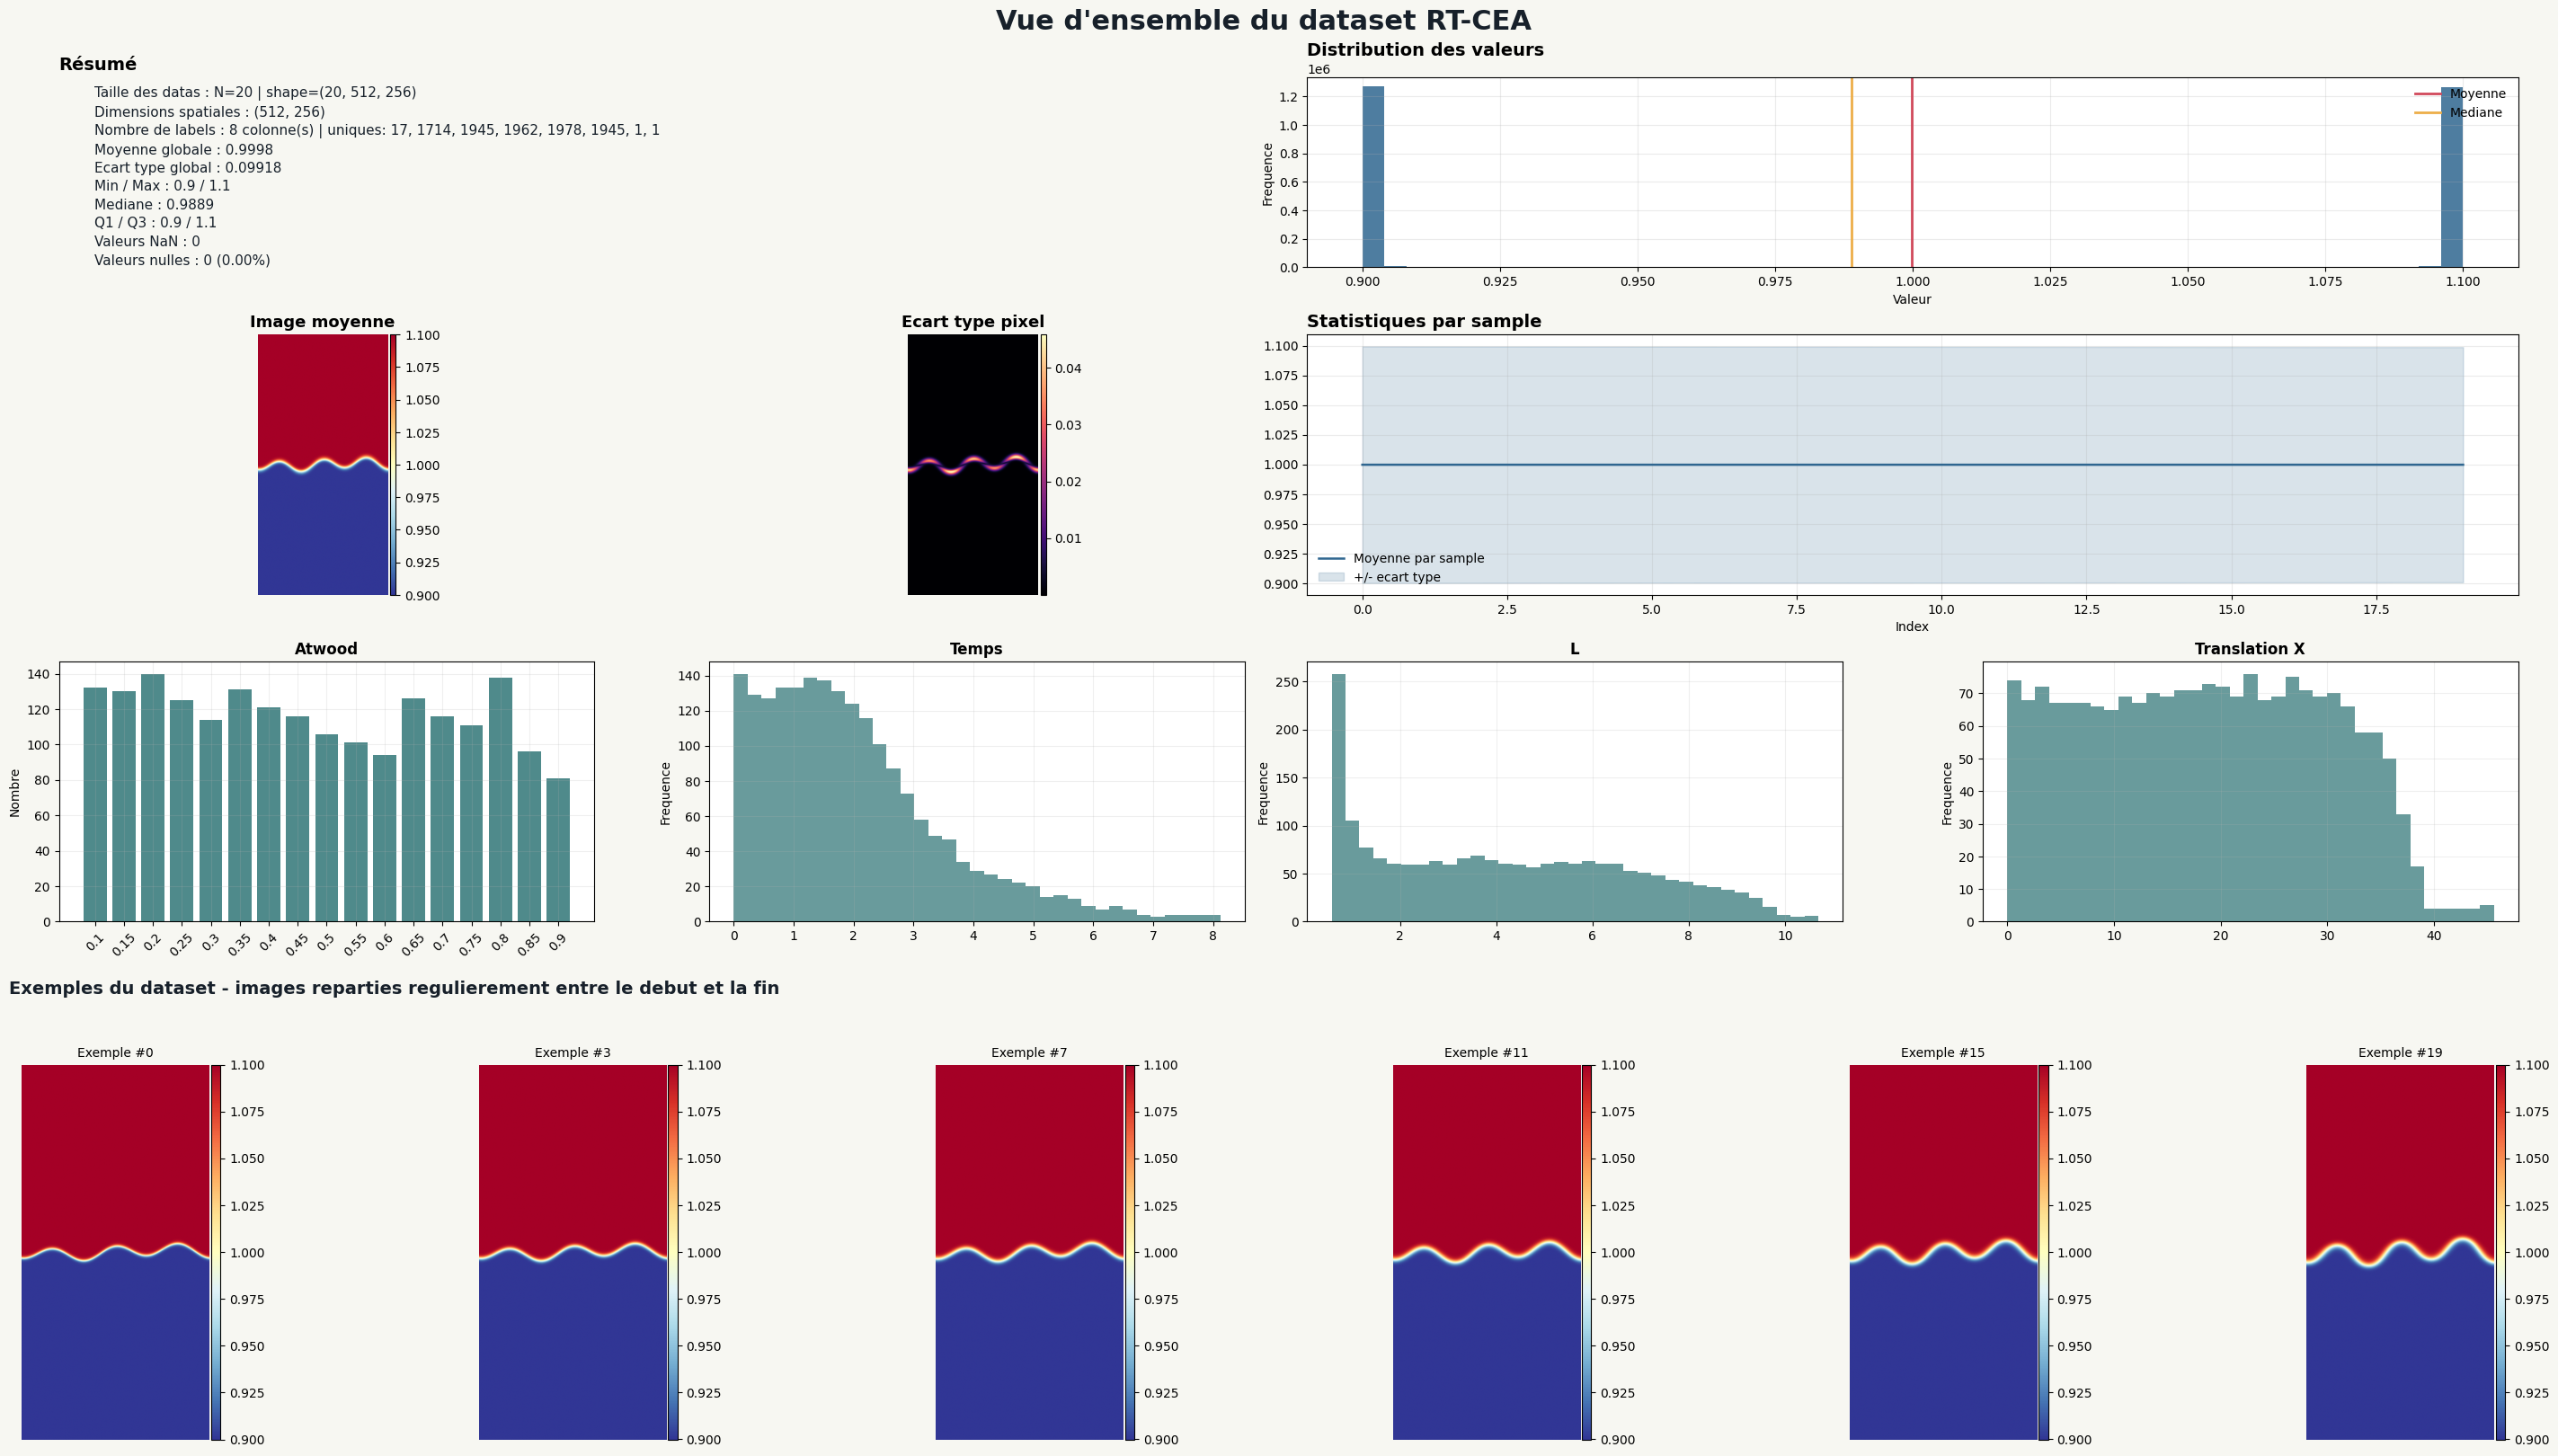

In [6]:
plot_dataset_overview(data, labels=labels, title="Vue d'ensemble du dataset RT-CEA", bins=50, save=True, save_path="outputs/simple_bimode_overview.png")

## Augmantation

In [8]:
img = data[5]
lab = labels[5]
# imageplot(img, cmap='RdYlBu_r', colorbar=True)

(20, 512, 256)


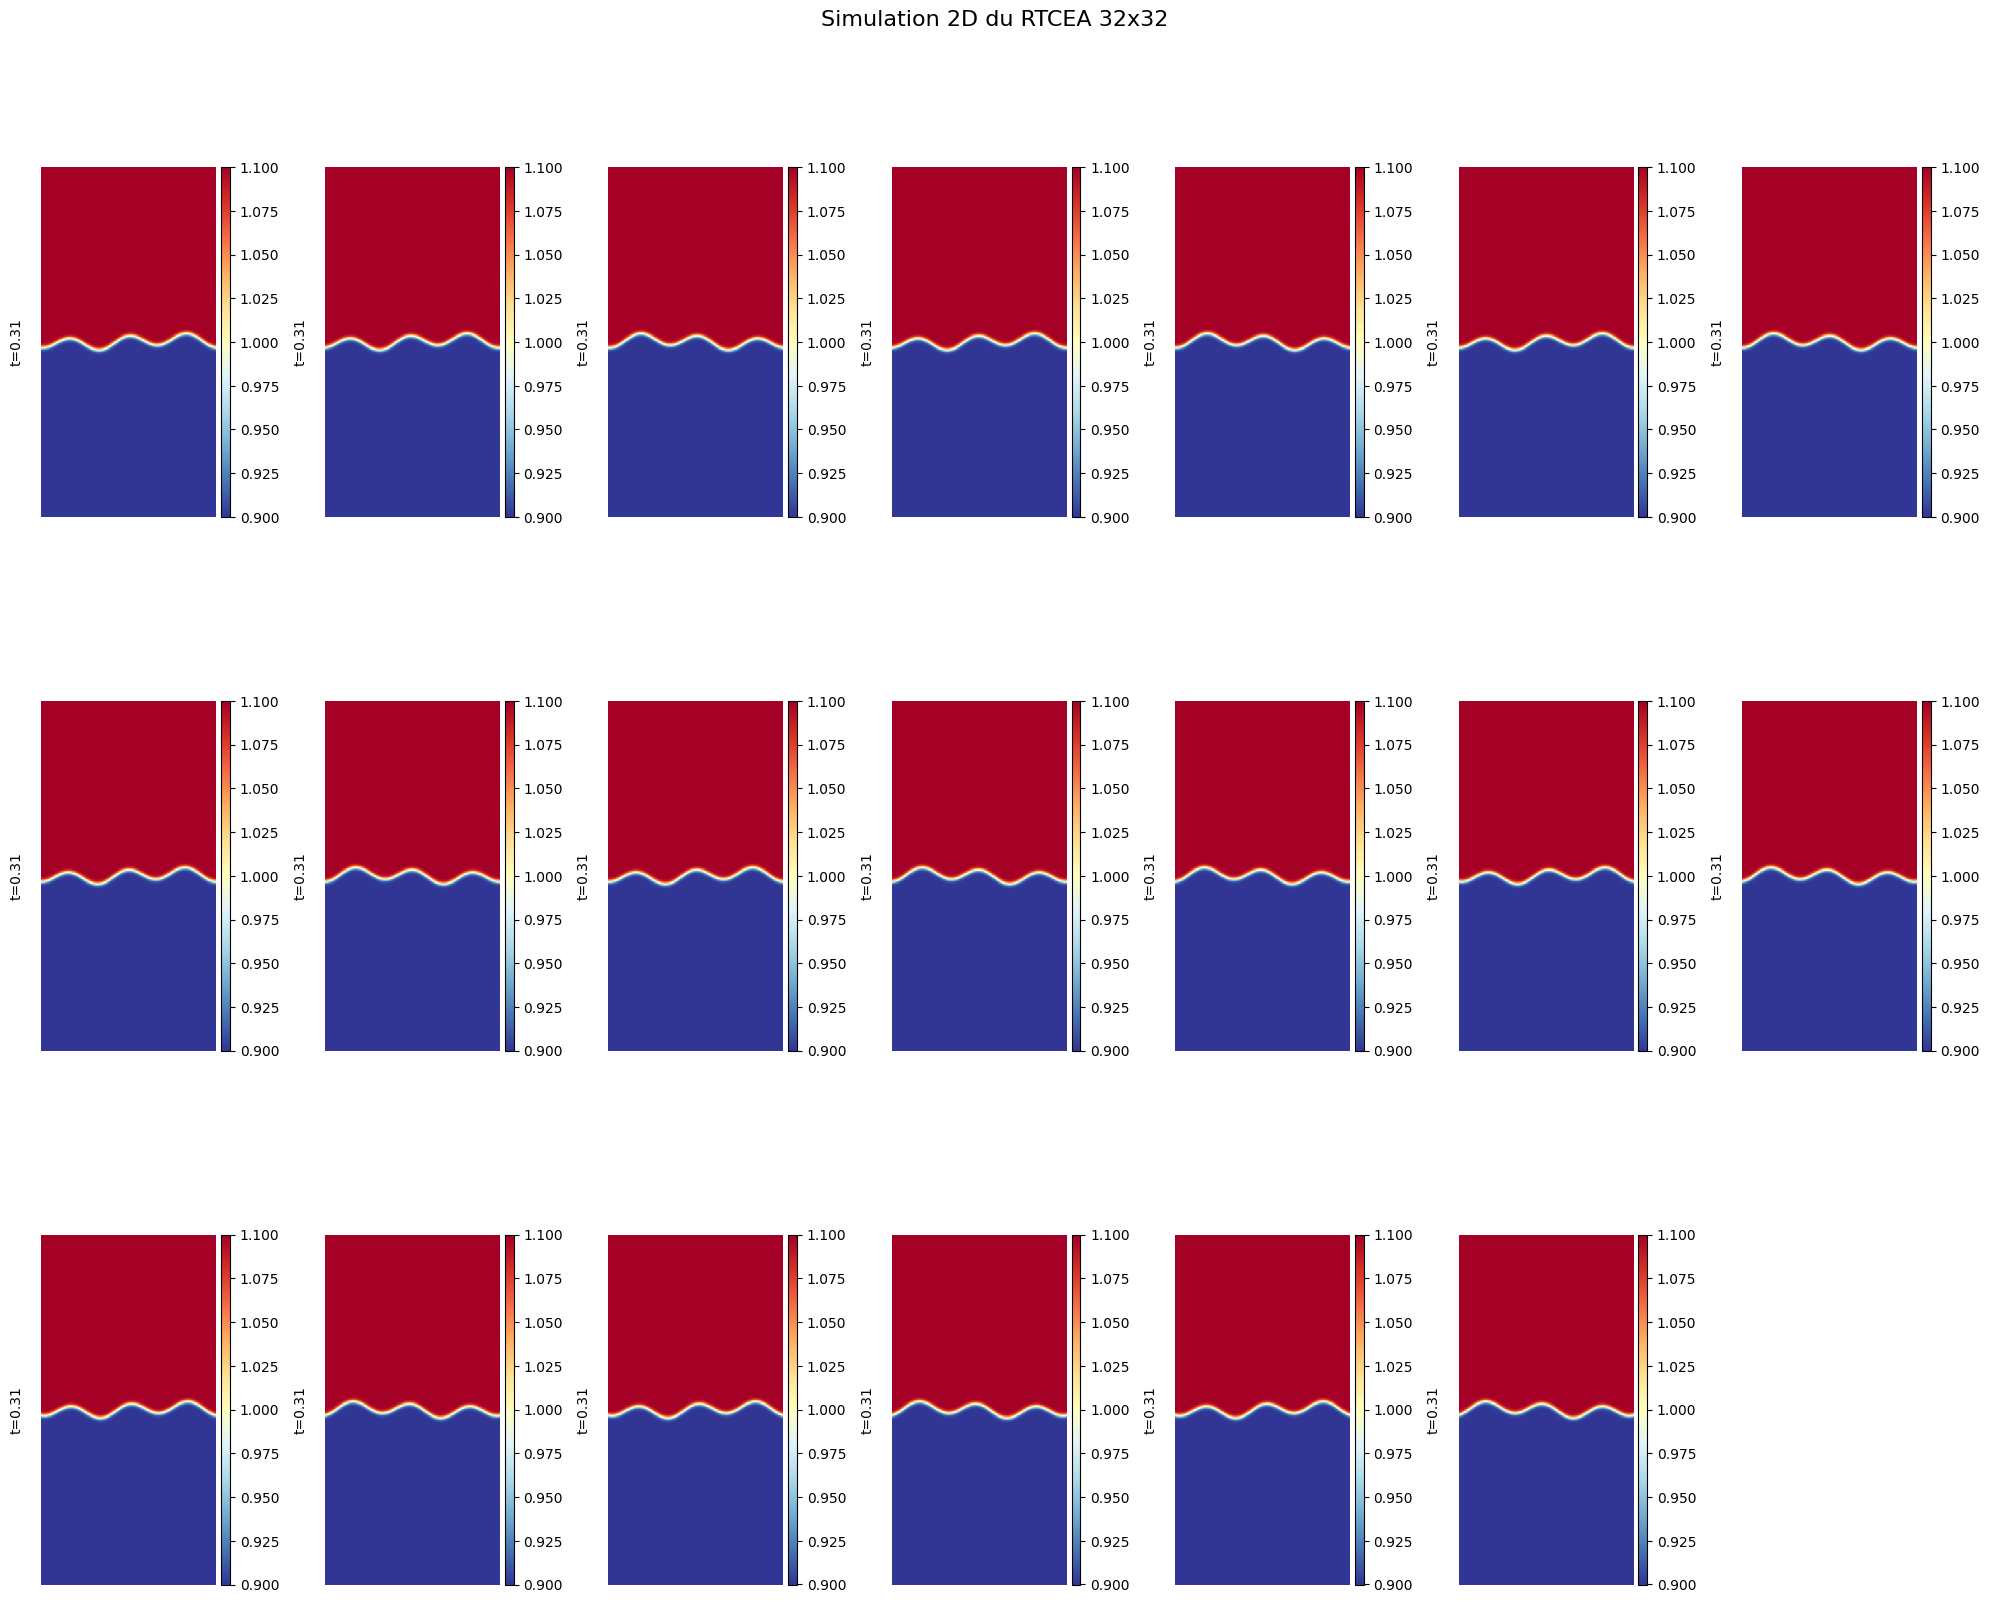

In [9]:
imgs, labs = augmentation(img, lab)
print(imgs.shape)  # (22, 32, 32)

t_labs = labs[:, 1]  # Extraire les labels de temps
plot_sim_2d_from_to(imgs, t_labs, 0, 19, 20, titre="Simulation 2D du RTCEA 32x32", save=False)


In [11]:
data_augmanted_images, data_augmented_labels = data_augmentater(data, labels, log=True)

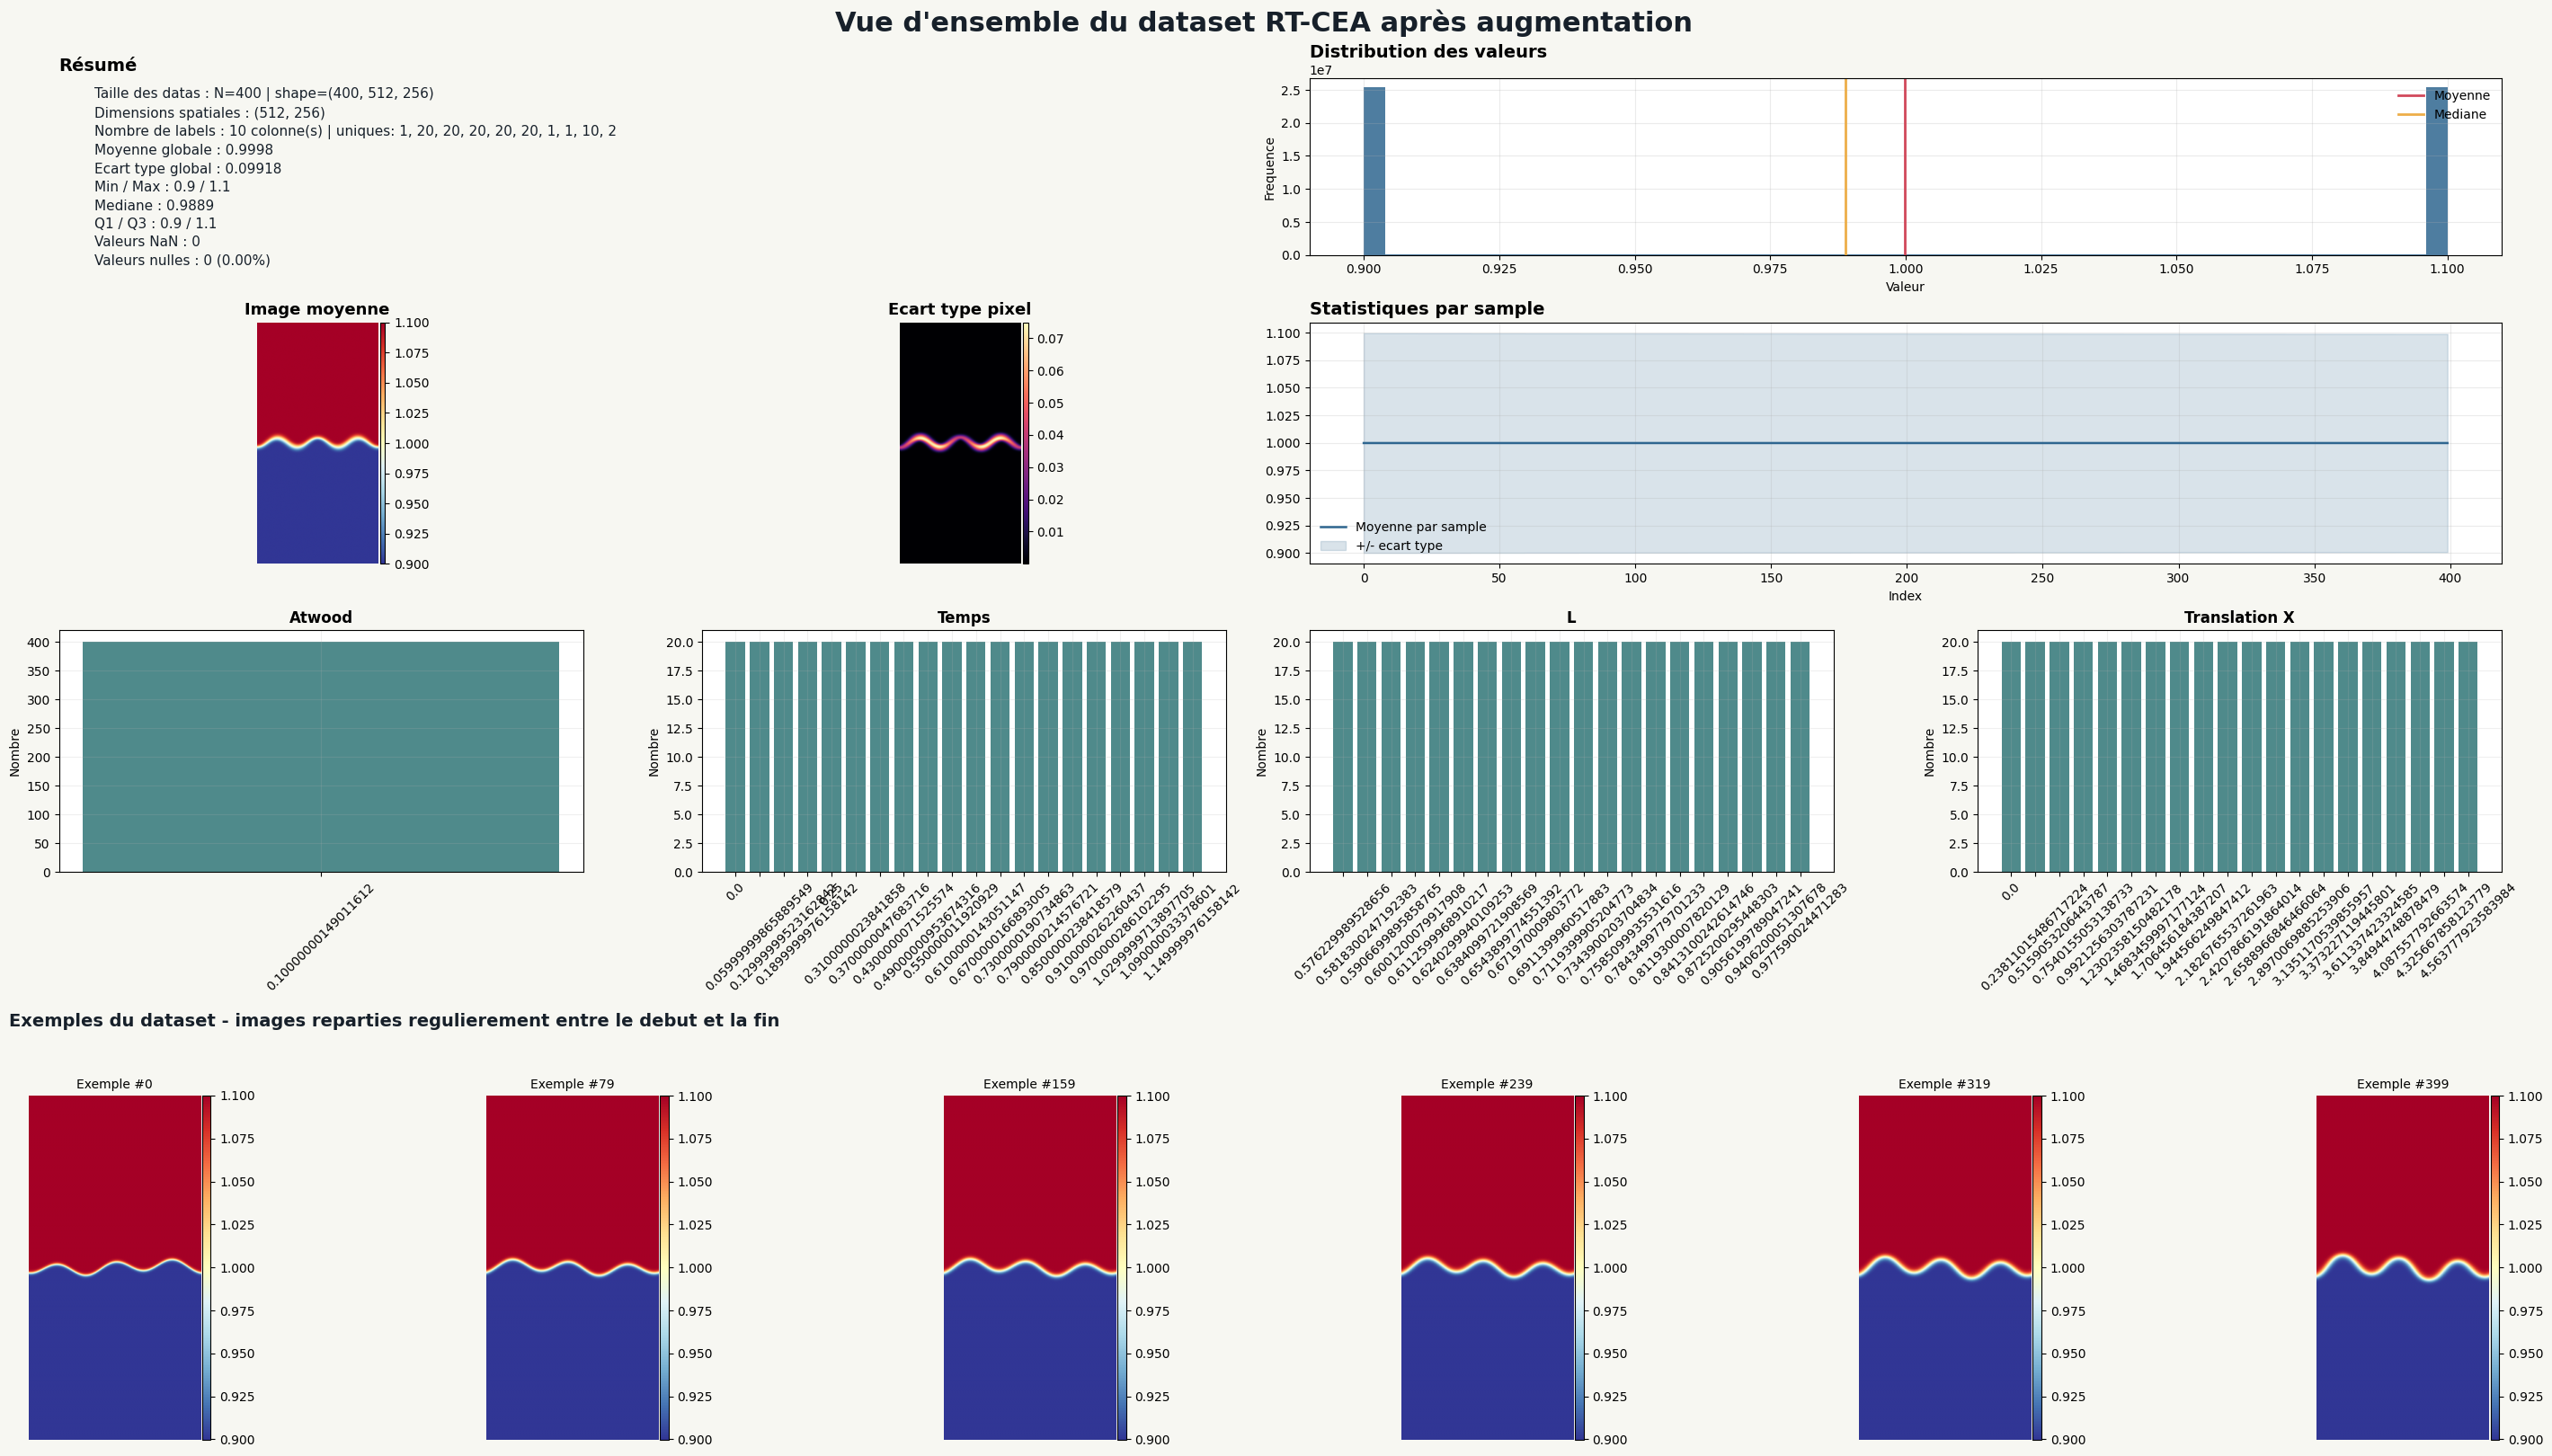

In [12]:
plot_dataset_overview(data_augmanted_images, labels=data_augmented_labels, title="Vue d'ensemble du dataset RT-CEA après augmentation", bins=50)

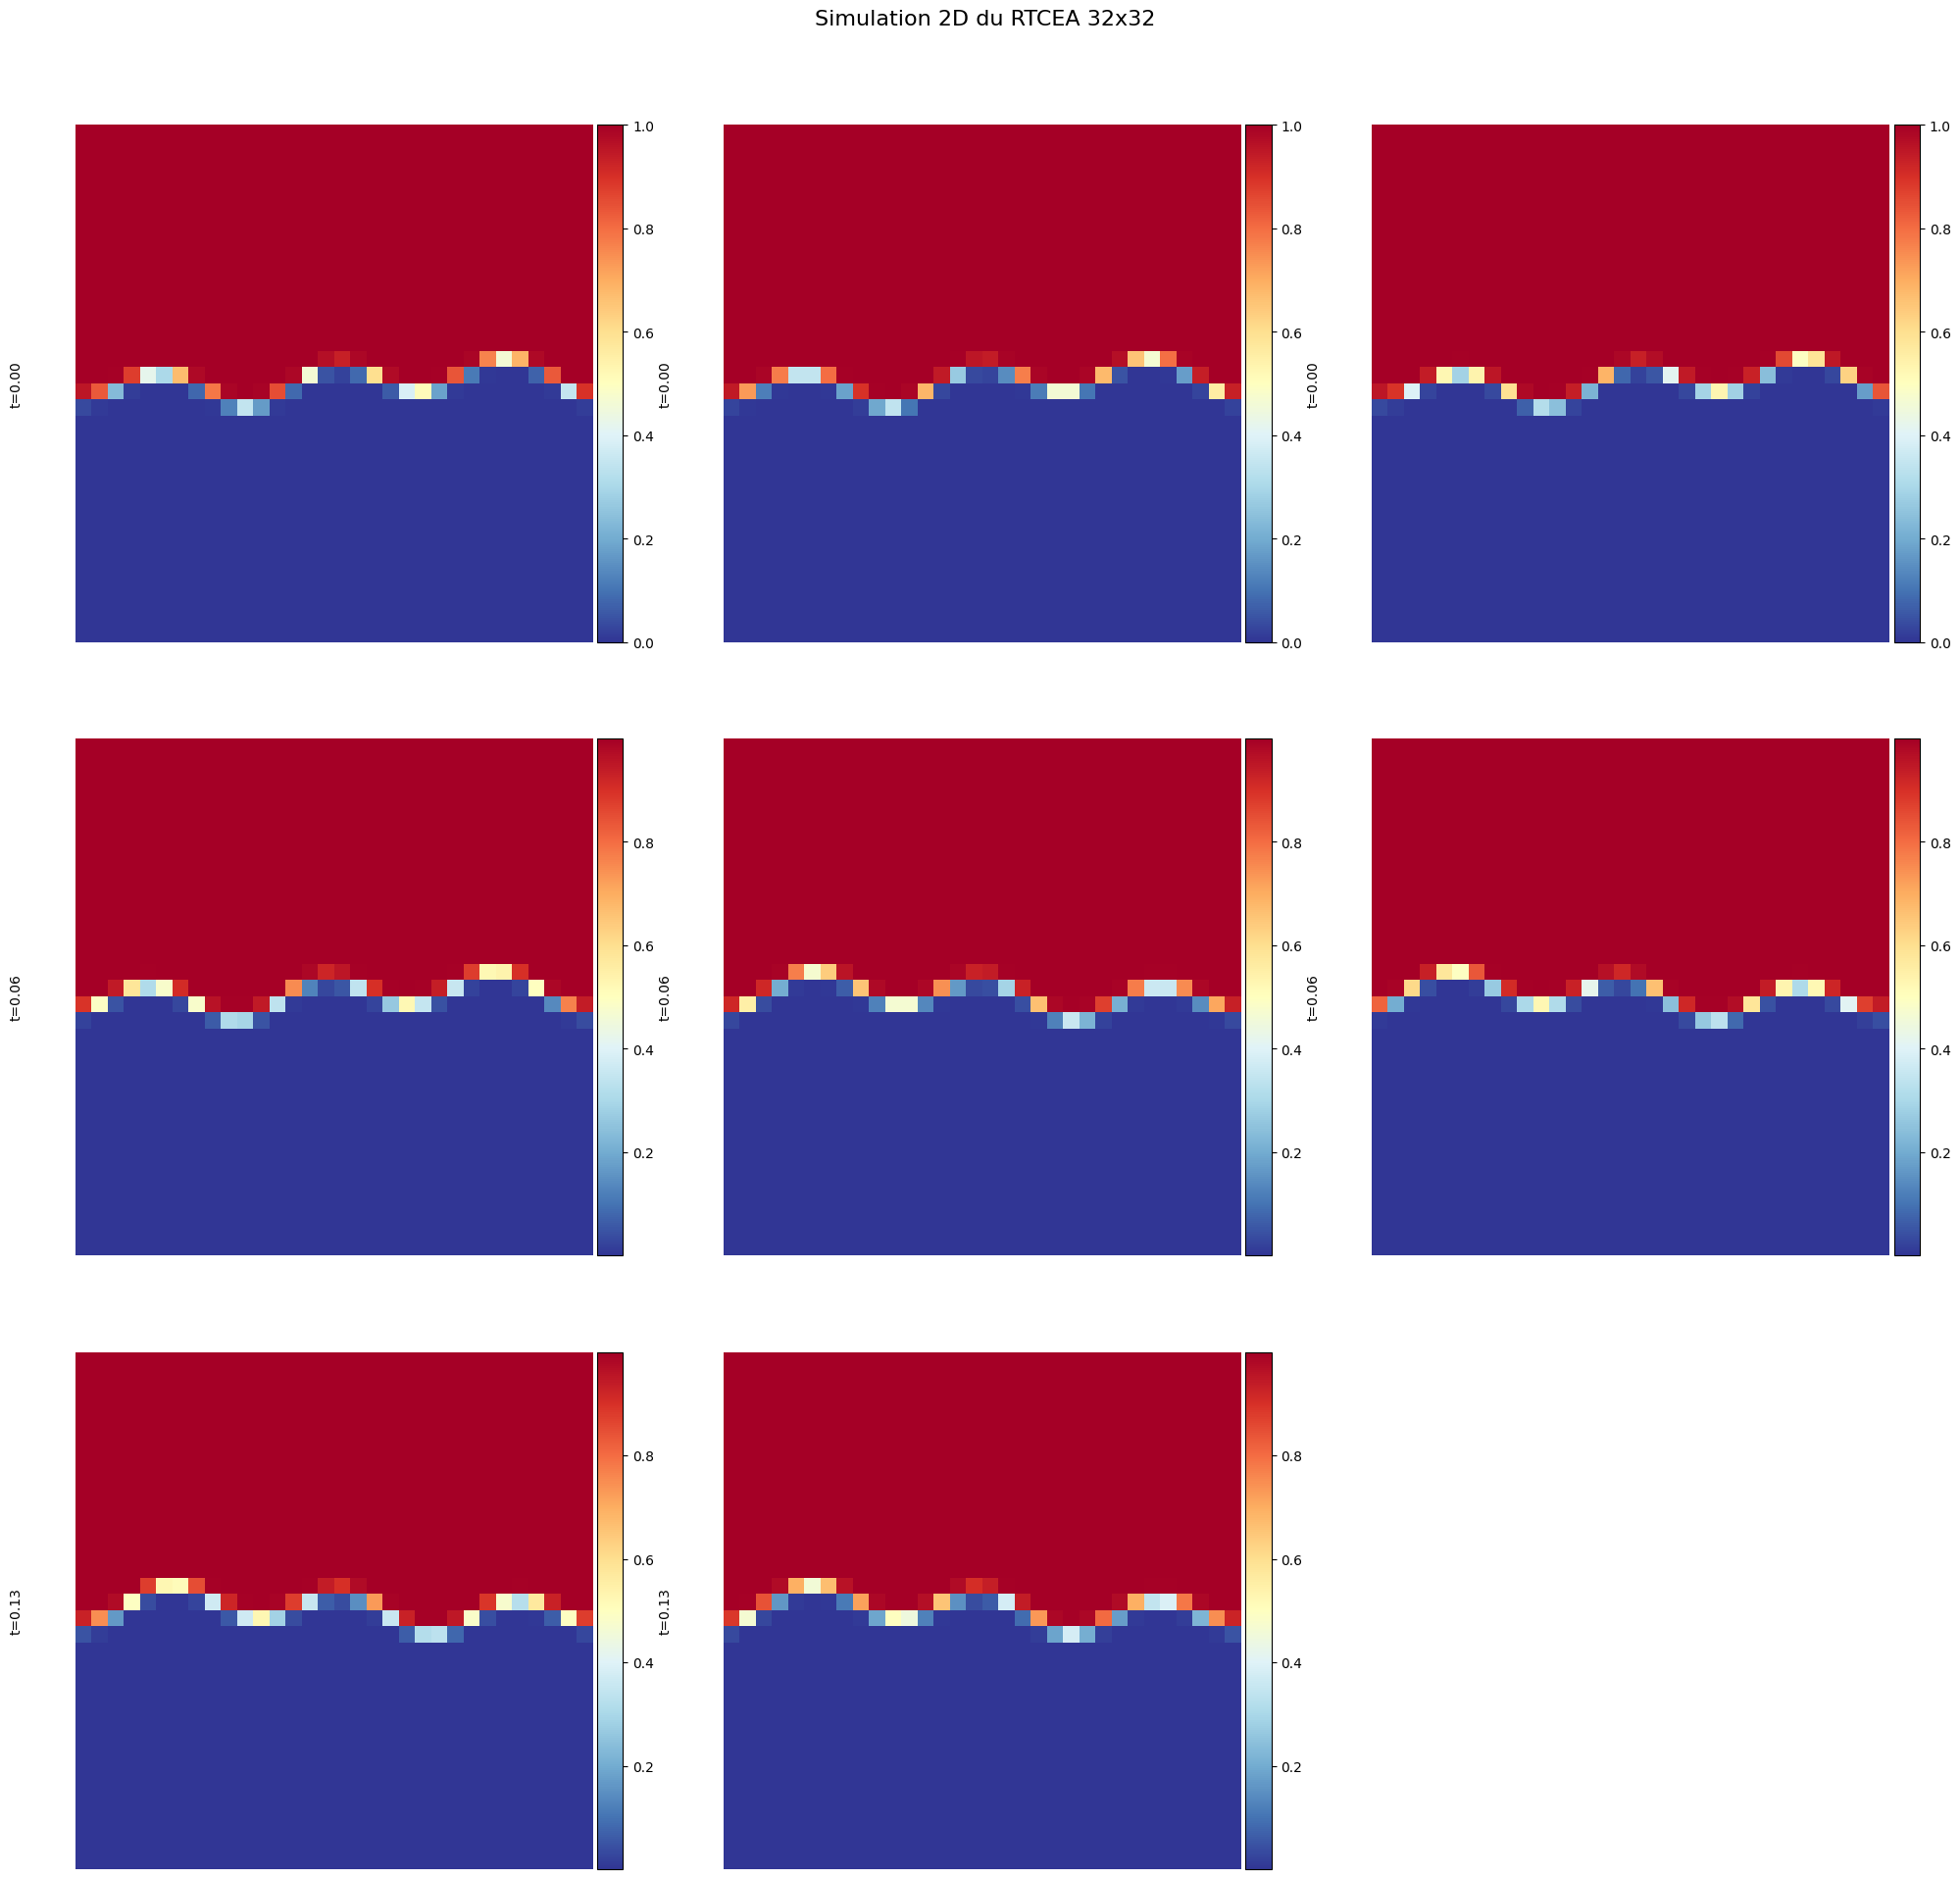

In [16]:
data_norm, new_labels = data_preprocessing(data_augmanted_images, data_augmented_labels, resize=32)
plot_sim_2d_from_to(data_norm, new_labels[:, 1], 0, 50, 8, titre="Simulation 2D du RTCEA 32x32", save=False)